# Summary statistics y metodos de `sbi`

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana06_sbi_03.ipynb)

Ya vimos que, en el flujo de trabajo de `sbi`, necesitamos un simulador que genere datos $x$ a partir de parametros $\theta$, junto con una prior desde la cual podamos muestrear muchos valores de esos parametros. Con el dataset de pares $(\theta_i, x_i)$ entrenamos luego un modelo para aproximar la posterior condicional $P(\theta \mid x)$.

El problema es que, en muchos simuladores, la salida $x$ tiene dimension muy alta. Eso ocurre por ejemplo con imagenes, campos espaciales o trayectorias temporales largas. Entrenar una red neuronal directamente sobre esos datos puede resultar costoso o incluso inviable.

En esta notebook vamos a explorar una solucion muy comun: reemplazar los datos completos por un conjunto mas compacto de cantidades derivadas, llamadas **summary statistics**.

## Parte 1

### Un simulador de dinamica molecular


En este ejemplo trabajaremos con un simulador unidimensional de dinamica molecular. El sistema contiene cuatro atomos de argon que interactuan mediante fuerzas derivadas de un potencial. Una de las descripciones mas simples para esta interaccion es el potencial de [Lennard-Jones](https://es.wikipedia.org/wiki/Potencial_de_Lennard-Jones), que combina una parte repulsiva y una parte atractiva:

$$
V(r) = 4 \epsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right].
$$

Si tomamos la fuerza como el gradiente negativo de la energia potencial, obtenemos
$$
\|\vec{F}(r)\| = 48 \epsilon  \sigma^{12} / r^{13} - 24  \epsilon  \sigma^{6}/r^7,
$$
donde omitimos la direccion vectorial, que coincide con la recta que une a las particulas que interactuan. Como tenemos una expresion analitica para la fuerza, podemos usar las leyes de Newton para obtener aceleracion, velocidad y posicion en cada instante, una vez fijadas las condiciones iniciales.

El simulador que resuelve estas ecuaciones esta implementado en `md.py`.


In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

import pickle
from scipy.signal import find_peaks
import os

# Herramientas relacionadas con sbi
import sbi.utils as utils
from sbi.inference import SNPE, simulate_for_sbi
from sbi.analysis import pairplot
from sbi.neural_nets import posterior_nn
from sbi.utils.user_input_checks import (
    process_prior,
    process_simulator,
) 
from sbi.utils.sbiutils import seed_all_backends

# Importamos el simulador 1D de dinamica molecular
from md import run_md, FlexibleBoxUniform

num_cpus = os.cpu_count()
workers = num_cpus - 1
print(f"Se encontraron {num_cpus} nucleos. Se usaran {workers}.")
seed_all_backends(24)

Se encontraron 8 nucleos. Se usaran 7.


Veamos ahora cuales son las entradas y salidas del simulador.

In [8]:
run_md?

Signature:
run_md(
    dt,
    number_of_steps,
    x,
    initial_temp,
    epsilon,
    sigma,
    box_length=20,
    seed=None,
)
Docstring:
Run a molecular dynamics (MD) simulation using the velocity Verlet algorithm.

Parameters
----------
dt : float
    The timestep length (s).
number_of_steps : int
    Number of iterations in the simulation.
x : ndarray of floats
    The initial positions of the particles in a single dimension (Å).
initial_temp : float
    Temperature of the system at initialization (K).
epsilon : float
    Depth of the potential well in the Lennard-Jones potential (energy units).
sigma : float
    Finite distance at which the inter-particle potential is zero (Å).
box_length : float, optional, default=20
    Length of the simulation box (Å).
seed : int, optional, default=None
    Random seed for reproducibility.

Returns
-------
positions : ndarray of floats
    The positions of all particles at each timestep of the simulation (Å).
    Shape: (number_of_steps, n

Una simulacion queda completamente determinada cuando fijamos los parametros del potencial de Lennard-Jones $\epsilon$ y $\sigma$, las posiciones iniciales $\vec{x_0}$ de los atomos y la temperatura del sistema. Ademas, hace falta especificar el paso temporal.

## Parte 2

### Datos observados

Supongamos ahora que medimos las trayectorias de los cuatro atomos en una caja de longitud 20 durante 800 segundos. Cargamos esos datos observados y los graficamos.

In [9]:
with open("observation_free.pkl", "rb") as pf:
    t, x_truth = pickle.load(pf)

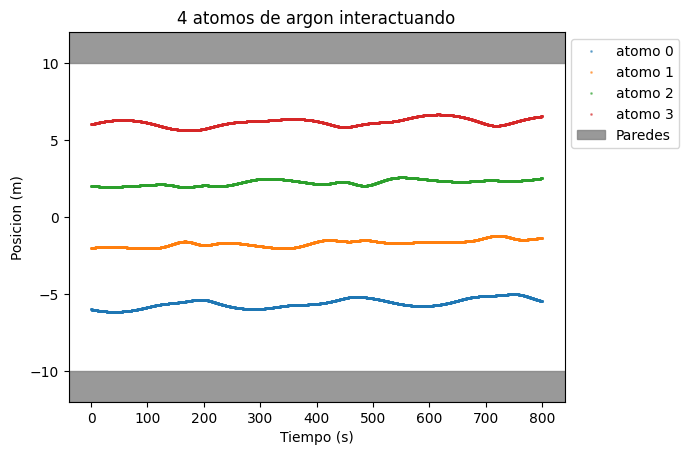

In [10]:
# Conocemos la longitud de la caja
box_length = 20

# Graficamos los datos observados
for i in range(0, x_truth.shape[1]):
    plt.plot(t, x_truth[:, i], 'o', ms=1, label=f"atomo {i}", alpha=0.5)
plt.ylim(-box_length * 0.6, box_length * 0.6)
plt.axhspan(box_length/2, plt.ylim()[1], color='gray', alpha=0.8, label="Paredes")
plt.axhspan(plt.ylim()[0], -box_length/2, color='gray', alpha=0.8)
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel("Tiempo (s)")
plt.ylabel("Posicion (m)")
plt.title("4 atomos de argon interactuando")
plt.show()

Las trayectorias contienen informacion sobre el potencial que sienten las particulas. Como las posiciones iniciales fueron medidas, podemos tratarlas como cantidades fijas. Lo que no conocemos son los parametros del potencial y la temperatura del sistema, que son justamente las cantidades que queremos inferir.

In [11]:
# Extraemos las posiciones iniciales
x0 = x_truth[0, :]

# Calculamos el paso temporal
dt = t[1] - t[0]

Recordemos que la temperatura se mide en Kelvin, mientras que $\epsilon$ y $\sigma$ estan en escalas compatibles con distancias y energias atomicas.

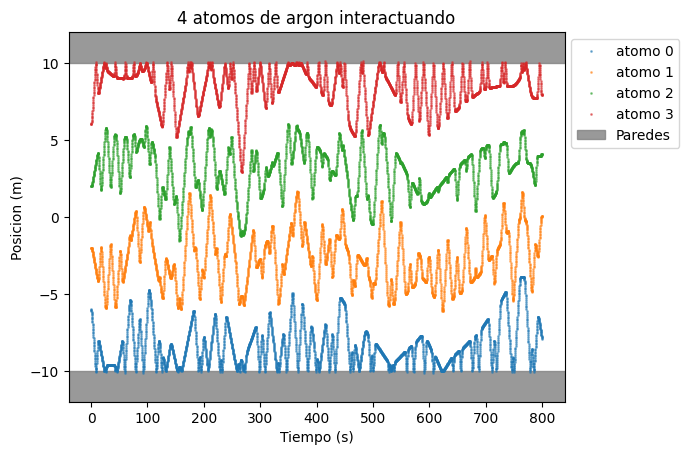

In [12]:
def create_x(theta):
        T, epsilon, sigma = theta.numpy()
        return run_md(dt, len(t), x0, T, epsilon, sigma, box_length=box_length)

def plot_single(theta):
    x = create_x(theta)
    for i in range(0, x_truth.shape[1]):
        plt.plot(t, x[:, i], 'o', ms=1, label=f"atomo {i}", alpha=0.5)
    plt.ylim(-box_length * 0.6, box_length * 0.6)
    plt.axhspan(box_length/2, plt.ylim()[1], color='gray', alpha=0.8, label="Paredes")
    plt.axhspan(plt.ylim()[0], -box_length/2, color='gray', alpha=0.8)
    plt.legend(bbox_to_anchor=(1,1))
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Posicion (m)")
    plt.title("4 atomos de argon interactuando")
    plt.show()

T = 100 # Kelvin
epsilon = 0.1 # eV/Angstrom
sigma = 5 # angstrom

theta_test = torch.tensor([T, epsilon, sigma])
plot_single(theta_test)

## Parte 3

### Introduccion a las summary statistics

Si quisieramos seguir el flujo de trabajo de `sbi` usando las trayectorias completas como entrada, la red tendria que procesar un volumen enorme de informacion. Eso implicaria entradas de alta dimension, modelos mas grandes y entrenamiento mas costoso.

La alternativa es construir **summary statistics**, es decir, cantidades mas compactas que conserven informacion relevante de las trayectorias. En este problema, una inspeccion visual sugiere varias opciones utiles:

- distancia promedio entre pares de atomos: con 4 atomos hay $(4 \times 3)/2 = 6$ distancias posibles entre pares;
- energia promedio: a partir de las posiciones podemos estimar velocidades y luego una energia cinetica media;
- cantidad de picos y valles: usando `find_peaks` sobre las desviaciones al cuadrado obtenemos una medida de cuan oscilatoria es cada trayectoria.

De esta forma, para un parametro $\theta=(T,\epsilon,\sigma)$ construimos un vector de dimension 11 que resume la informacion contenida en decenas de miles de puntos simulados.

In [13]:
def pairwise_distances(x):
    """
    Calculate pairwise distances between particles in a 2D array of positions.
    
    Args:
        x (numpy.ndarray): 2D array of positions of the particles in the simulation.
    """
    n = x.shape[1]
    i, j = np.triu_indices(n, k=1)
    distances = np.abs(x[:, i] - x[:, j])
    return distances

def calculate_average_energy(dt, x):
    """
    Calculate the average kinetic energy of a system of particles.
    
    Args:
        dt (float): Time step of the molecular dynamics simulation.
        x (numpy.ndarray): 2D array of positions of the particles in the simulation.
    
    Returns:
        float: Average kinetic energy of the system.
    """
    v = np.diff(x, axis=0)/dt # shape becomes (9999, 4)
    KE = 1./2. * np.sum(v**2, axis=1) # shape becomes (9999,)
    average_energy = np.mean(KE)
    return average_energy

def create_summary(theta):
    """
    Calculate summary statistics of a molecular dynamics simulation.
    
    Args:
        theta (numpy.ndarray): Parameter values of the molecular dynamics simulation.
    
    Returns:
        numpy.ndarray: 1D array of summary statistics, in the order of pairwise distances, number of peaks, and average kinetic energy.
    """
    T, epsilon, sigma = theta.numpy()
    x = run_md(dt, len(t), x0, T, epsilon, sigma)
    avg_pairwise_distance = pairwise_distances(x).mean(axis=0)
    num_cp = np.array(
        [len(find_peaks(i)[0]) for i in ((x - x.mean(axis=0)) ** 2).T]
    )
    average_energy = np.array([calculate_average_energy(dt, x)])
    return np.concatenate([avg_pairwise_distance, num_cp, average_energy], axis=0)

Probemos estas summary statistics sobre el valor de prueba $\theta$ que acabamos de usar.

In [14]:
summary_test = create_summary(theta_test)
print(summary_test)
print(summary_test.size)

[  5.55729041  11.42698631  16.99287648   5.86969589  11.43558606
   5.56589017 100.          82.          82.          93.
   0.26748508]
11


## Parte 4

### Definir la prior y preparar el simulador

Para comenzar el flujo de trabajo de `sbi`, definimos una prior razonable sobre los tres parametros que queremos inferir.

In [15]:
prior_min = torch.as_tensor([1e-3, 0.005, 1.6])
prior_max = torch.as_tensor([2000.0, 0.05, 5.0])
prior = FlexibleBoxUniform(
        low=prior_min, high=prior_max
    )

Tambien elegimos automaticamente el dispositivo de computo disponible.

In [16]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

Luego verificamos la prior y adaptamos el simulador al formato esperado por `sbi`.

In [17]:
# Simulamos en CPU usando multiples nucleos
n_samples = 10000
prior.to("cpu")
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulate_x = process_simulator(create_x, prior, prior_returns_numpy)

Con todo eso listo, ejecutamos las simulaciones para `sbi`. Este paso puede tomar tiempo y es un buen ejemplo de por que el acceso a computo paralelo o HPC resulta util en inferencia basada en simulaciones.

In [18]:
%%time
theta_traj, x_traj = simulate_for_sbi(
    simulate_x, prior, num_simulations=1000, num_workers=workers
)

100%|██████████| 1000/1000 [00:35<00:00, 27.79it/s]

CPU times: user 3.59 s, sys: 351 ms, total: 3.94 s
Wall time: 36.3 s


Despues de simular, podemos visualizar algunas trayectorias generadas. Como la prior es bastante amplia, aparecen tanto trayectorias muy oscilatorias como otras mucho mas suaves.

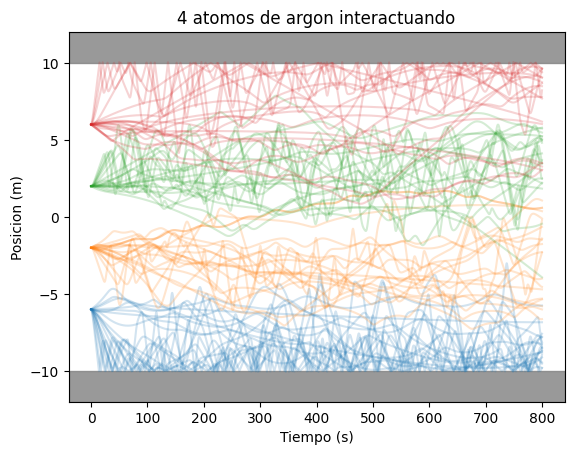

In [19]:
for i, ci in zip(range(0, x_traj.shape[2]), mcolors.TABLEAU_COLORS):
    for j in range(20):
        plt.plot(t, x_traj[np.random.choice(1000), :, i], color=ci, alpha=0.2)
plt.ylim(-box_length * 0.6, box_length * 0.6)
plt.axhspan(10, plt.ylim()[1], color='gray', alpha=0.8)
plt.axhspan(plt.ylim()[0], -10, color='gray', alpha=0.8)
plt.xlabel("Tiempo (s)")
plt.ylabel("Posicion (m)")
plt.title("4 atomos de argon interactuando")
plt.show()

## Parte 5

### Entrenar `sbi` usando summary statistics

Para usar `sbi` con summary statistics, necesitamos transformar cada trayectoria simulada en su vector resumido correspondiente. Una forma de hacerlo es aplicar `create_summary` a cada trayectoria; otra, mas conveniente, es envolver directamente esa funcion con `process_simulator`.

In [20]:
simulate_summary = process_simulator(create_summary, prior, prior_returns_numpy)

In [ ]:
%%time
# Generamos summary statistics
theta, x_summary = simulate_for_sbi(
        simulate_summary, prior, num_simulations=n_samples, num_workers=workers
    )

 11%|█         | 1097/10000 [00:38<04:59, 29.70it/s]

Ahora que ya tenemos pares del tipo $(\theta, x_{summary})$, entrenamos una red neuronal para aprender la posterior condicional $P(\theta \mid x_{summary})$.

In [ ]:
# Entrenamos la red neuronal
prior.to(device)
inference = SNPE(prior=prior, device=device)
density_estimator = inference.append_simulations(theta.to(device),
                                                 x_summary.to(device),
                                                proposal=prior,
                                                exclude_invalid_x=True).train(training_batch_size=256,
                                                                              learning_rate=0.01,
                                                                              show_train_summary=True)

/p/project1/atmlaml/robledo1/ICS/sbi_intro/sbi_env/venv/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:157: UserWarning: Data x has device 'cuda:0'. Moving x to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/p/project1/atmlaml/robledo1/ICS/sbi_intro/sbi_env/venv/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:157: UserWarning: Parameters theta has device 'cuda:0'. Moving theta to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(


 Neural network successfully converged after 117 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 117
        Best validation performance: 3.1054
        -------------------------
        


Si hay GPU disponible, podemos entrenar alli y luego mover el modelo a CPU para hacer inferencia. Como el muestreo posterior no es demasiado costoso, este cambio suele ser conveniente.

In [ ]:
inference._neural_net.to("cpu")
posterior = inference.build_posterior(prior=prior.to("cpu"))

Calculamos ahora las summary statistics del dato observado, para poder muestrear la posterior en torno a ese resumen.

In [ ]:
# Generamos las summary statistics del dato observado
avg_pairwise_distance = pairwise_distances(x_truth).mean(axis=0)
num_cp = np.array(
    [len(find_peaks(i)[0]) for i in ((x_truth - x_truth.mean(axis=0)) ** 2).T]
)
average_energy = [calculate_average_energy(dt, x_truth)]
x_summary_o = torch.as_tensor(np.concatenate([avg_pairwise_distance, num_cp, average_energy], axis=0))

theta_p = posterior.sample((10000,), x=x_summary_o)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

## Comentarios finales

Con eso ya tenemos todo lo necesario para inspeccionar las distribuciones posteriores estimadas. Solo para evaluar visualmente el resultado, mostramos tambien los valores reales con los que se generaron las trayectorias observadas.

In [ ]:
# En un problema real, este valor normalmente no se conoce
theta_o = (600, 0.0103, 3.4)

Graficamos entonces el resultado para analizar la capacidad inferencial del modelo.

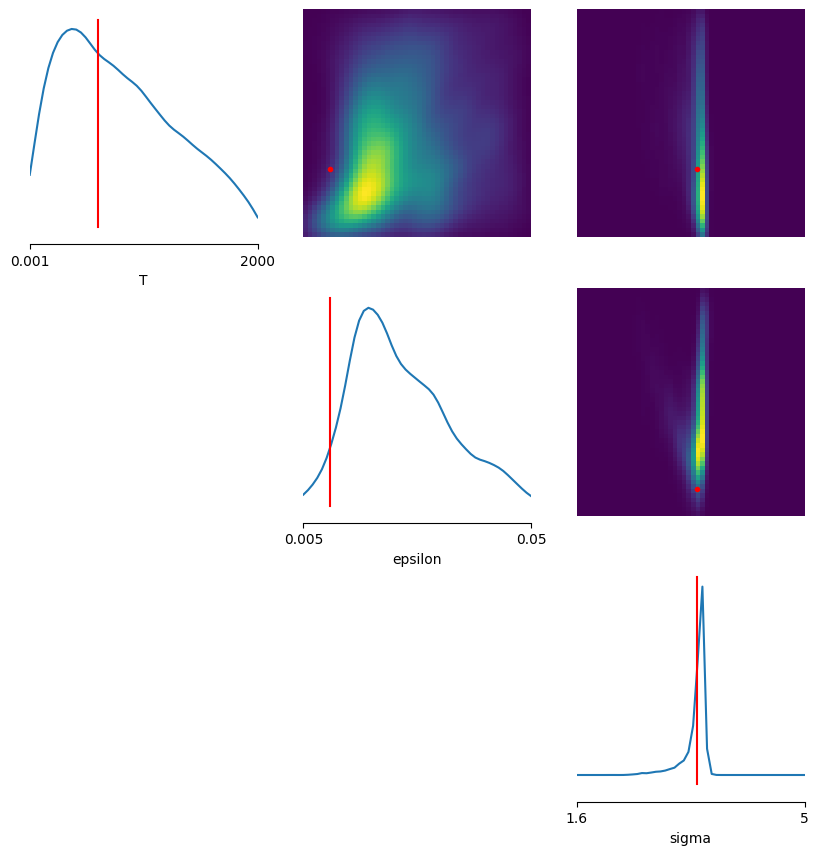

In [ ]:
fig, axes = pairplot(
        theta_p,
        limits=list(zip(prior_min, prior_max)),
        ticks=list(zip(prior_min, prior_max)),
        fig_kwargs={
            "figsize": (7, 7),
            "points_offdiag": {"markersize": 6},
            "points_colors": "r",
        },
        labels=["T", "epsilon", "sigma"],
        upper="kde",
        diag="kde",
        points=theta_o,
    )
plt.show()

Usando `sbi` junto con summary statistics, logramos inferir los parametros del potencial de Lennard-Jones y la temperatura del sistema sin tener que alimentar a la red con las trayectorias completas.

La idea central es que las summary statistics incorporan conocimiento del problema y reducen mucho la dimension de la entrada. En un caso real, podriamos probar otros resumenes o enriquecer los actuales para mejorar la calidad de la inferencia.